# Fundamentals of Machine Learning — Exercise 2
## Exploratory Data Analysis and Statistical Properties

In this exercise, you will continue working with the **House Prices** dataset. The focus is not on writing long programs. Most code is already prepared. Your task is to use the output to answer analytical questions.

We will use the same workflow as in Exercise 1:

> **question → prediction → computation → visualisation → interpretation → verification**

### Learning outcomes

By the end of the exercise, you should be able to:

- distinguish a variable's analytical role from its Pandas `dtype`,
- choose between the mean, median, standard deviation, and IQR,
- describe the shape and spread of a numerical distribution,
- interpret an ordinal variable without treating it as a continuous measurement,
- investigate whether a missing value means “unknown” or “not applicable”,
- choose a graph based on an analytical question,
- interpret Pearson and Spearman correlation cautiously,
- flag unusual observations and investigate them before removing them,
- use an AI chatbot as a tutor without letting it replace your own explanation.

**Recommended duration:** 90 minutes


## How to work in this exercise

Most code is already available. Your task is to:

1. **predict** what you expect before running a cell,
2. **choose** a suitable statistic or visualisation,
3. **interpret** the result in your own words,
4. **verify** an important claim using another output,
5. **modify** only a small part of the code when the question changes.

Do not copy a chatbot's explanation into the notebook. When AI is used, you will first write your own answer, let the chatbot ask you questions, close the chat, and then explain the idea again in your own words.

### Suggested pair-work routine

- Student A predicts or explains the expected result.
- Student B runs the code and checks the output.
- Both agree on a short interpretation.
- Swap roles for the next activity.


## 0. Imports and dataset

We will use the same dataset as in Exercise 1. Each row represents one recorded house sale.


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


In [4]:
DATA_URL = (
    "https://raw.githubusercontent.com/jplatos/VSB-FEI-Fundamentals-of-Machine-Learning/refs/heads/master/Datasets/zsu_cv1_data.csv"
)

LOCAL_DATA_PATH = Path("zsu_cv1_data.csv")
data_source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.exists() else DATA_URL

df_full = pd.read_csv(data_source)

print(f"Source: {data_source}")
print(f"Shape: {df_full.shape[0]} rows × {df_full.shape[1]} columns")
df_full.head()


Source: https://raw.githubusercontent.com/jplatos/VSB-FEI-Fundamentals-of-Machine-Learning/refs/heads/master/Datasets/zsu_cv1_data.csv
Shape: 1460 rows × 81 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.00",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.00",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.00",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.00",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.00",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Build an analytical map

Pandas reports how a column is stored. An analyst must also decide what the values **mean**.

We will focus on a smaller set of variables.


In [8]:
focus_columns = [
    "Id",
    "MSSubClass",
    "OverallQual",
    "OverallCond",
    "GarageFinish",
    "BldgType",
    "Neighborhood",
    "YearBuilt",
    "GrLivArea",
    "GarageArea",
    "SalePrice",
]

df = df_full.loc[:, focus_columns].copy()

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique(dropna=True),
    "example": [
        df[column].dropna().iloc[0] if df[column].notna().any() else np.nan
        for column in df.columns
    ],
})

profile


,dtype,missing,unique_values,example
Id,int64,0,1460,1
MSSubClass,int64,0,15,60
OverallQual,int64,0,10,7
OverallCond,int64,0,9,5
GarageFinish,object,81,3,RFn
BldgType,object,0,5,1Fam
Neighborhood,object,0,25,CollgCr
YearBuilt,int64,0,112,2003
GrLivArea,int64,0,861,1710
GarageArea,int64,0,441,548


In [7]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=profile)

KeyboardInterrupt: 

### Activity 1 — Assign analytical roles

For each variable, choose the most suitable role:

- **identifier**
- **categorical code**
- **ordinal variable**
- **continuous measurement**
- **nominal category**
- **target variable**

| Variable | Your role | Why? |
|---|---|---|
| `Id` | Identiefier |  |
| `MSSubClass` | Categorical code |  |
| `OverallQual` | ordinal variable |  |
| `Neighborhood` |nominal category  |  |
| `GrLivArea` | continuous measurement |  |
| `SalePrice` | target variable |  |

Then answer:

1. Why is `dtype` alone insufficient?
2. What incorrect assumption would we make if `MSSubClass` were treated as an ordinary measurement?


In [ ]:
dtype only describes how a value is stored in Pansas , not what the value means

In [ ]:
Differents variables can have the same dtype but different analytical roles

### Stop and explain

Choose one of the six variables and explain its role to a classmate without using the words “integer”, “float”, or “object”. Use only its real-world meaning.


## 2. What is a typical sale price?

A numerical distribution can be summarised in several ways. The choice should depend on its shape and on the analytical question.

### Predict before running

1. Do you expect the mean sale price to be higher or lower than the median?
I expect the mean sale prie to be higher than the median.

2. Which measure should react more strongly to a very expensive house: the median or the mean?
The mean should react more strongly to a very expensive house.

3. Which pair describes the middle 50% of the data: mean and standard deviation, or Q1 and Q3? Q1 ans Q3 describe the middle 50% of the data .



In [9]:
sale_price = df["SalePrice"].dropna()

q1 = sale_price.quantile(0.25)
median = sale_price.median()
q3 = sale_price.quantile(0.75)

sale_price_summary = pd.Series({
    "count": sale_price.count(),
    "mean": sale_price.mean(),
    "median": median,
    "standard_deviation": sale_price.std(),
    "Q1": q1,
    "Q3": q3,
    "IQR": q3 - q1,
    "minimum": sale_price.min(),
    "maximum": sale_price.max(),
    "skewness": sale_price.skew(),
})

sale_price_summary


,0
count,"1,460.00"
mean,"180,921.20"
median,"163,000.00"
standard_deviation,"79,442.50"
Q1,"129,975.00"
Q3,"214,000.00"
IQR,"84,025.00"
minimum,"34,900.00"
maximum,"755,000.00"
skewness,1.88


### Activity 2 — Read the statistical summary

Answer briefly:

1. What price would you report as the **typical** sale price: the mean or the median? Why?
I would use the median because its less affected by very expensives houses.
2. Between which two values does the middle 50% of sale prices lie?
The middle 50% of the sale prices lies between Q1 ans Q3.
3. What does the positive skewness suggest about the distribution?
It means that the distribution is skewed to the right, with some very expensives houses.
4. Why is the standard deviation less robust than the IQR?
The standard deviation is more affected by extreme values, while the IQR only look a the middle 50% of the data.


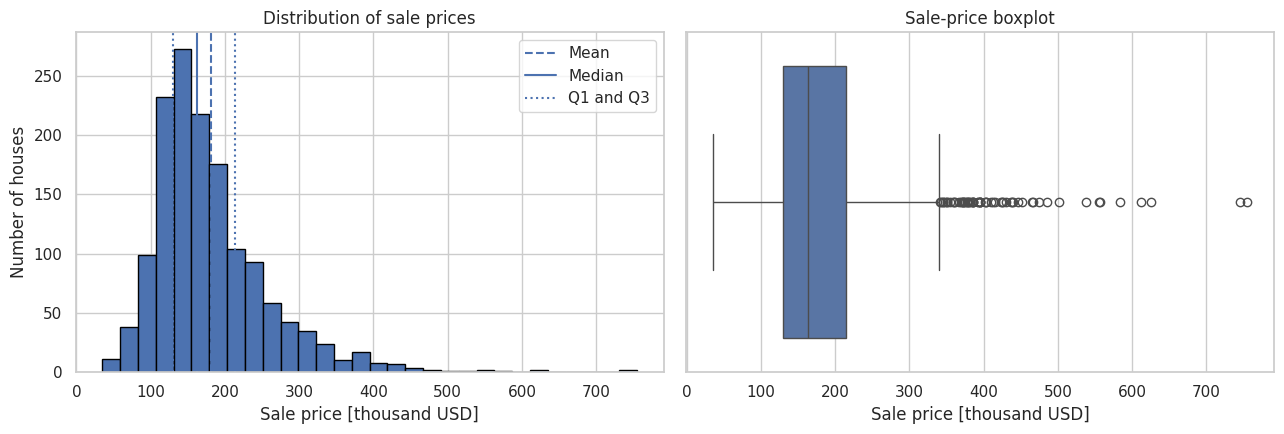

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(sale_price / 1_000, bins=30, edgecolor="black")
axes[0].axvline(sale_price.mean() / 1_000, linestyle="--", label="Mean")
axes[0].axvline(median / 1_000, linestyle="-", label="Median")
axes[0].axvline(q1 / 1_000, linestyle=":", label="Q1 and Q3")
axes[0].axvline(q3 / 1_000, linestyle=":")
axes[0].set(
    title="Distribution of sale prices",
    xlabel="Sale price [thousand USD]",
    ylabel="Number of houses",
)
axes[0].legend()

sns.boxplot(x=sale_price / 1_000, ax=axes[1])
axes[1].set(
    title="Sale-price boxplot",
    xlabel="Sale price [thousand USD]",
)

plt.tight_layout()
plt.show()


### Interpretation checkpoint

Write three short sentences:

1. describe the shape of the distribution,
2. explain the difference between the mean and median,
3. state one thing visible in the histogram but not clearly visible in the boxplot.

its an histogram
the mean is higher than the median because the very expensibve houses pull the mean upwards

### Verification challenge — one extreme value

Before running the cell, predict which quantities will change most when one sale price is replaced by 2,000,000 USD.


In [11]:
counterfactual_price = sale_price.copy()
counterfactual_price.loc[counterfactual_price.idxmax()] = 2_000_000

comparison = pd.DataFrame({
    "original": {
        "mean": sale_price.mean(),
        "median": sale_price.median(),
        "standard_deviation": sale_price.std(),
        "IQR": sale_price.quantile(0.75) - sale_price.quantile(0.25),
    },
    "after one extreme value": {
        "mean": counterfactual_price.mean(),
        "median": counterfactual_price.median(),
        "standard_deviation": counterfactual_price.std(),
        "IQR": (
            counterfactual_price.quantile(0.75)
            - counterfactual_price.quantile(0.25)
        ),
    },
})

comparison["absolute_change"] = (
    comparison["after one extreme value"] - comparison["original"]
)

comparison


,original,after one extreme value,absolute_change
mean,"180,921.20","181,773.94",852.74
median,"163,000.00","163,000.00",0.00
standard_deviation,"79,442.50","91,392.14","11,949.64"
IQR,"84,025.00","84,025.00",0.00


Compare the result with your prediction.

- Which two measures changed most?
- Which two measures were almost unchanged?
- Does this experiment prove that the median is always better than the mean? Explain.


### Guided AI study activity — learn through questions

First, write your own one-sentence answer:

> Why may the median be a better description of a typical house price in this dataset?

Then open an AI chatbot and use the prompt below.

```text
I am learning the difference between the mean, median, standard deviation, and IQR.
I have already analysed a right-skewed house-price distribution.
Do not give me a lecture or a final answer.
Ask me one short question at a time, at most four questions.
Help me work out:
1. which measures react strongly to one extreme value,
2. which measures are more robust,
3. when the mean can still be useful.
At the end, ask me to summarise the idea in two sentences.
```

Close the chatbot and complete this note **from memory**:

**My answer before the chat:**  
The median may be better beacause some very exspensive houses can invcrease the mean.
**One question that made me reconsider something:**  
Why is the median less affected by extreme values?
**My final two-sentence explanation:**  The median is more robust because extreme values have little effect on it. The mean and standard deviation are more sensitive to extreme values, while the IQR is more robust.

**A different real-world example where the same idea matters:**
Household income is a good example because a few very high incomes can increase the mean a lot, while the median can better represent a typical income.

## 3. Numbers can represent ordered categories

`OverallQual` and `OverallCond` are stored as integers from 1 to 10. They have an order, but the distance between neighbouring ratings is not guaranteed to be equal.


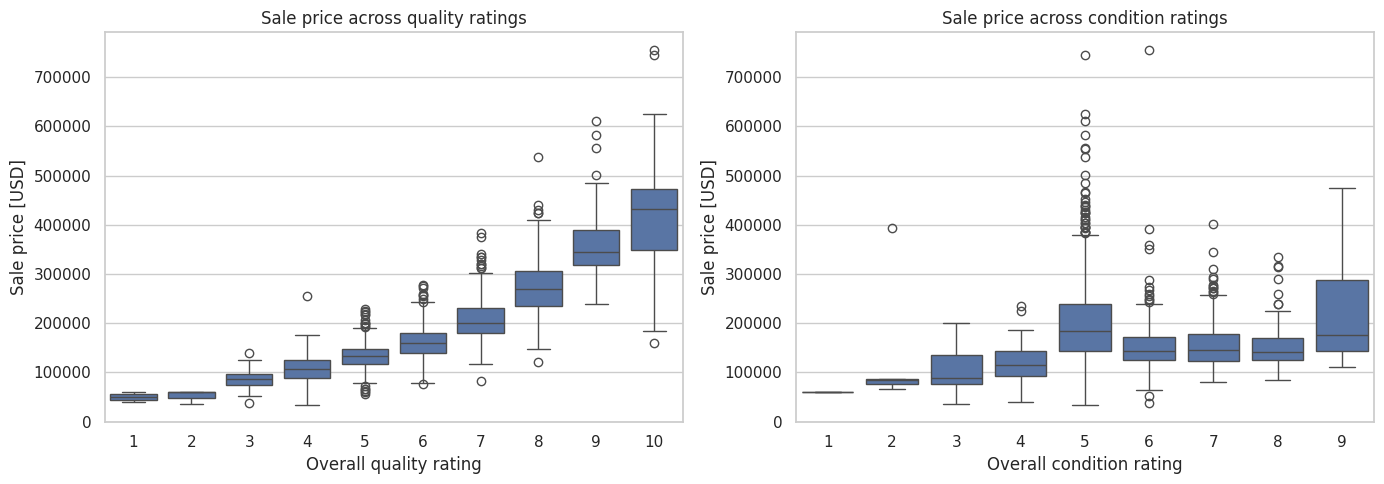

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="OverallQual", y="SalePrice", ax=axes[0])
axes[0].set(
    title="Sale price across quality ratings",
    xlabel="Overall quality rating",
    ylabel="Sale price [USD]",
)

sns.boxplot(data=df, x="OverallCond", y="SalePrice", ax=axes[1])
axes[1].set(
    title="Sale price across condition ratings",
    xlabel="Overall condition rating",
    ylabel="Sale price [USD]",
)

plt.tight_layout()
plt.show()


### Activity 3 — Compare quality and condition

1. Which variable shows clearer separation of sale prices across its levels?
2. Is the relationship perfectly increasing at every step?
3. Why is a boxplot more informative here than a line joining the group means?
4. Complete the sentence carefully:

> Houses with a higher `OverallQual` rating tend to ...

Do **not** use the word “cause”.


In [ ]:
quality_summary = (
    df.groupby("OverallQual", observed=True)
      .agg(
          houses=("Id", "count"),
          median_price=("SalePrice", "median"),
          mean_price=("SalePrice", "mean"),
      )
)

quality_summary


### Verification checkpoint

Use the table to verify one claim that you made from the boxplot. Also identify one quality level with a relatively small group size. Why should small groups be interpreted cautiously?


## 4. Missing values can have different meanings

A missing value may mean:

- the value is unknown,
- the value was not recorded,
- the variable is not applicable,
- the real-world feature is absent.

We will investigate `GarageFinish` instead of replacing its missing values immediately.


In [ ]:
garage_columns = [
    "GarageType",
    "GarageFinish",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
]

garage = df_full.loc[:, garage_columns].copy()
garage["GarageFinishMissing"] = garage["GarageFinish"].isna()

print("Missing values in garage-related columns:")
display(garage.isna().sum().to_frame("missing_count"))

print("Numerical garage properties by GarageFinish missingness:")
display(
    garage.groupby("GarageFinishMissing")[["GarageCars", "GarageArea"]]
          .agg(["count", "median", "min", "max"])
)

print("GarageFinish × GarageType:")
display(
    pd.crosstab(
        garage["GarageFinish"].fillna("<missing>"),
        garage["GarageType"].fillna("<missing>"),
        dropna=False,
    )
)


### Activity 4 — Build an evidence chain

Complete the statements:

1. **Initial hypothesis:** Missing `GarageFinish` may mean ...
2. **Evidence from `GarageArea` and `GarageCars`:** ...
3. **Evidence from `GarageType`:** ...
4. **Most defensible interpretation:** ...
5. **What should be checked before using the same solution for another column?** ...


In [ ]:
missing_finish_with_positive_area = garage.loc[
    garage["GarageFinish"].isna()
    & garage["GarageArea"].fillna(0).gt(0)
]

print(
    "Rows with missing GarageFinish but positive GarageArea:",
    len(missing_finish_with_positive_area),
)

garage["GarageFinishEDA"] = garage["GarageFinish"].fillna("NoGarage")
garage["GarageFinishEDA"].value_counts(dropna=False)


### Stop and explain

Why is `NoGarage` a defensible category for this particular variable? Why would the rule “replace every missing categorical value with `No...`” be unsafe?


## 5. Choose a graph for the question

A graph should be selected from the analytical question, not from habit.


### Plot-selection activity

Match each question with a suitable first visualisation.

| Question | Choose from |
|---|---|
| A. What is the distribution of one numerical variable? | histogram / boxplot / scatter plot / count plot |
| B. How does a numerical variable differ across categories? | histogram / boxplot / scatter plot / count plot |
| C. How are two numerical variables related? | histogram / boxplot / scatter plot / count plot |
| D. How many observations belong to each category? | histogram / boxplot / scatter plot / count plot |

Then choose one question by changing `QUESTION_ID` in the next cell.


In [ ]:
QUESTION_ID = "B"  # Choose "A", "B", "C", or "D".

fig, ax = plt.subplots(figsize=(9, 5))

if QUESTION_ID == "A":
    sns.histplot(data=df, x="SalePrice", bins=30, ax=ax)
    ax.set(title="Distribution of sale price", xlabel="Sale price [USD]")

elif QUESTION_ID == "B":
    category_order = (
        df.groupby("BldgType")["SalePrice"]
          .median()
          .sort_values()
          .index
    )
    sns.boxplot(
        data=df,
        x="BldgType",
        y="SalePrice",
        order=category_order,
        ax=ax,
    )
    ax.set(
        title="Sale price across building types",
        xlabel="Building type",
        ylabel="Sale price [USD]",
    )

elif QUESTION_ID == "C":
    sns.scatterplot(
        data=df,
        x="GrLivArea",
        y="SalePrice",
        alpha=0.65,
        ax=ax,
    )
    ax.set(
        title="Living area and sale price",
        xlabel="Above-ground living area [ft²]",
        ylabel="Sale price [USD]",
    )

elif QUESTION_ID == "D":
    count_order = df["BldgType"].value_counts().index
    sns.countplot(data=df, x="BldgType", order=count_order, ax=ax)
    ax.set(
        title="Number of houses by building type",
        xlabel="Building type",
        ylabel="Number of houses",
    )

else:
    raise ValueError("QUESTION_ID must be A, B, C, or D.")

plt.tight_layout()
plt.show()


### Activity 5 — Read the plot as evidence

For your selected plot, write:

1. the analytical question,
2. the main visible pattern,
3. one quantity or relationship that the plot does **not** show,
4. one table or second plot that could verify your interpretation.


In [ ]:
building_type_summary = (
    df.groupby("BldgType", observed=True)
      .agg(
          houses=("Id", "count"),
          median_price=("SalePrice", "median"),
          median_area=("GrLivArea", "median"),
          price_IQR=(
              "SalePrice",
              lambda values: values.quantile(0.75) - values.quantile(0.25),
          ),
      )
      .sort_values("median_price", ascending=False)
)

building_type_summary


### Verification checkpoint

If you selected Question B, use the table above to check whether differences in typical price may partly reflect differences in typical living area or group size.

If you selected another question, create or describe a comparable verification table.


## 6. Correlation is a summary, not a conclusion

Correlation describes association. It does not establish causality, and it may hide nonlinear patterns, groups, or unusual observations.

### Predict before running

1. Which selected variable do you expect to have the strongest positive association with `SalePrice`?
2. Which variable is ordinal rather than continuous?
3. Why should `MSSubClass` not be added automatically just because it is stored as an integer?


In [ ]:
correlation_features = [
    "LotArea",
    "YearBuilt",
    "GrLivArea",
    "GarageArea",
    "OverallQual",
    "OverallCond",
    "SalePrice",
]

pearson_corr = df_full[correlation_features].corr(method="pearson")
spearman_corr = df_full[correlation_features].corr(method="spearman")

sale_price_correlations = pd.DataFrame({
    "Pearson": pearson_corr["SalePrice"],
    "Spearman": spearman_corr["SalePrice"],
}).drop(index="SalePrice")

sale_price_correlations["absolute_difference"] = (
    sale_price_correlations["Pearson"]
    - sale_price_correlations["Spearman"]
).abs()

sale_price_correlations.sort_values("Spearman", ascending=False)


In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
)

plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.show()


### Activity 6 — Interpret and verify correlation

1. Which variable has the strongest Pearson association with `SalePrice`?
2. Is the ordering exactly the same for Spearman correlation?
3. Choose one variable for which Pearson and Spearman differ noticeably. What property of the relationship might explain the difference?
4. Rewrite this statement so that it is defensible:

> `OverallQual` has the largest correlation, so improving quality by one point causes the sale price to rise by a fixed amount.


In [ ]:
VARIABLE_TO_VERIFY = "GrLivArea"  # Try "OverallQual" or another suitable variable.

fig, ax = plt.subplots(figsize=(8, 5))

if VARIABLE_TO_VERIFY in {"OverallQual", "OverallCond"}:
    sns.boxplot(
        data=df_full,
        x=VARIABLE_TO_VERIFY,
        y="SalePrice",
        ax=ax,
    )
else:
    sns.scatterplot(
        data=df_full,
        x=VARIABLE_TO_VERIFY,
        y="SalePrice",
        alpha=0.65,
        ax=ax,
    )

ax.set(
    title=f"Verification plot: {VARIABLE_TO_VERIFY} and SalePrice",
    ylabel="Sale price [USD]",
)
plt.tight_layout()
plt.show()


### Stop and explain

What does the verification plot reveal that the single correlation coefficient does not?


## 7. Outliers are investigation targets

The IQR rule can flag unusual values. It cannot decide whether a value is incorrect.

Possible outcomes include:

- keep the observation,
- correct a documented error,
- analyse the data with and without it,
- remove it only with a clear domain-based reason.


In [ ]:
def iqr_outlier_flag(series, multiplier=1.5):
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    flag = series.lt(lower) | series.gt(upper)

    return flag, {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
    }


sale_flag, sale_bounds = iqr_outlier_flag(df_full["SalePrice"])
area_flag, area_bounds = iqr_outlier_flag(df_full["GrLivArea"])

outlier_work = df_full.copy()
outlier_work["SalePriceOutlier"] = sale_flag
outlier_work["GrLivAreaOutlier"] = area_flag
outlier_work["AnyIQRFlag"] = sale_flag | area_flag

pd.DataFrame({
    "SalePrice": sale_bounds,
    "GrLivArea": area_bounds,
})


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=outlier_work,
    x="GrLivArea",
    y="SalePrice",
    hue="AnyIQRFlag",
    alpha=0.75,
    ax=ax,
)

ax.set(
    title="IQR-flagged observations",
    xlabel="Above-ground living area [ft²]",
    ylabel="Sale price [USD]",
)
plt.tight_layout()
plt.show()

inspection_columns = [
    "Id",
    "Neighborhood",
    "BldgType",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "GrLivArea",
    "GarageArea",
    "SaleCondition",
    "SalePrice",
    "SalePriceOutlier",
    "GrLivAreaOutlier",
]

flagged_examples = (
    outlier_work.loc[outlier_work["AnyIQRFlag"], inspection_columns]
                .sort_values(["GrLivArea", "SalePrice"], ascending=False)
)

flagged_examples.head(15)


### Activity 7 — Investigate one unusual observation

Choose one row from `flagged_examples` and answer:

1. Why was it flagged?
2. Are its values internally plausible?
3. Which related variables help explain it?
4. Could it strongly influence a correlation or later model?
5. What is your current decision: keep, correct, remove, or analyse both ways?

A valid decision may be: **keep it for now and perform a sensitivity analysis later**.


## 8. Integrated in-class investigation — not graded

Choose **one** question:

- Is house quality more strongly associated with price than house condition?
- Do larger houses always sell for more?
- Which building types show the greatest variation in sale price?
- Are newer houses generally rated as higher quality?
- Does a missing garage description usually indicate that the house has no garage?

Your investigation must include:

1. a clear analytical question,
2. an expectation written before analysis,
3. one suitable numerical summary,
4. one visualisation,
5. a short interpretation,
6. one verification step,
7. one limitation or alternative explanation.

Reuse and adapt earlier code. Do not start by asking an AI chatbot to generate the complete analysis.


In [ ]:
# Investigation title:
# Question:
# Expected result before analysis:
# Variables and their analytical roles:
# Why the selected summary and plot fit the question:

# Reuse and adapt one of the earlier analysis patterns here.


## Investigation summary

**Question:**  

**What I expected:**  

**What I found:**  

**How I verified it:**  

**One limitation or alternative explanation:**


### Optional AI reviewer — only after your own draft

After writing the summary above, you may use this prompt:

```text
Act as a careful statistics tutor.
Do not rewrite my answer and do not provide a model answer.
Read my short interpretation and ask me exactly two questions:
1. one question about whether my evidence supports my claim,
2. one question about a limitation or alternative explanation.
Wait for my answer after each question.
```

Record only:

**One claim I kept unchanged and why:**  

**One claim I revised and why:**  

Do not paste the whole conversation.


# End-of-lab self-check

Before finishing, check that you can:

- [ ] distinguish `dtype` from analytical role,
- [ ] explain when the median and IQR are useful,
- [ ] describe a right-skewed distribution,
- [ ] interpret an ordinal rating cautiously,
- [ ] investigate the meaning of a missing value before filling it,
- [ ] select a plot based on a question,
- [ ] explain why correlation does not prove causality,
- [ ] use a second output to verify a claim,
- [ ] investigate an outlier before deciding what to do with it,
- [ ] explain what you learned from AI without reading the chat transcript.

These skills form the EDA part of the semester project. Exercise 3 will continue with scaling, distance, and K-means clustering.
